# EDA da Estação Pedra Guaratiba

Este notebook será usado para a análise exploratória individual da **Estação Pedra Guaratiba**. Nesta primeira etapa, vamos montar a **auditoria da base**, que serve para verificar se a série da estação é confiável e em quais períodos ela apresenta melhor ou pior qualidade.


## Carregamento da base

Primeiro, carregamos a base consolidada de qualidade do ar e isolamos apenas os registros da estação de Pedra Guaratiba. Como o nome da estação pode vir com problema de codificação, fazemos uma normalização simples para garantir um filtro robusto.


In [1]:
import pandas as pd
import unicodedata
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
url_air_quality_data = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/MonitorAr/InitialMergedData/merged_air_quality_data.csv"

df_air_quality = pd.read_csv(url_air_quality_data)
df_pedra_guaratiba = df_air_quality[df_air_quality["Nome"] == "ESTAÇÃO PEDRA DE GUARATIBA"].copy()

print("Dimensoes da base da Estacao Pedra de Guaratiba:", df_pedra_guaratiba.shape)
display(df_pedra_guaratiba.head())

Dimensoes da base da Estacao Pedra de Guaratiba: (61367, 15)


,data,Nome,chuva,temp,ur,so2,no2,co,no,nox,o3,pm10,pm2_5,lat,lon
1,2012-01-01 00:30:00,ESTAÇÃO PEDRA DE GUARATIBA,0.8,24.07,99.56,NaN,NaN,NaN,NaN,NaN,24.52,74.0,NaN,-23.004379,-43.62901
11,2012-01-01 01:30:00,ESTAÇÃO PEDRA DE GUARATIBA,1.2,24.07,99.40,NaN,NaN,NaN,NaN,NaN,28.16,34.0,NaN,-23.004379,-43.62901
19,2012-01-01 02:30:00,ESTAÇÃO PEDRA DE GUARATIBA,0.4,24.17,96.38,NaN,NaN,NaN,NaN,NaN,42.38,41.0,NaN,-23.004379,-43.62901
27,2012-01-01 03:30:00,ESTAÇÃO PEDRA DE GUARATIBA,0.6,24.03,94.49,NaN,NaN,NaN,NaN,NaN,45.37,17.0,NaN,-23.004379,-43.62901
40,2012-01-01 04:30:00,ESTAÇÃO PEDRA DE GUARATIBA,0.2,23.88,97.84,NaN,NaN,NaN,NaN,NaN,29.45,22.0,NaN,-23.004379,-43.62901


## Auditoria da base


### 1. Período coberto e frequência observada

Nesta célula verificamos o intervalo temporal da base, o número de timestamps únicos, o intervalo mais frequente entre observações e a distribuição do minuto da medição. Isso ajuda a confirmar se a série realmente se comporta como uma série **horária**.


In [4]:
df_pedra_guaratiba["data"] = pd.to_datetime(df_pedra_guaratiba["data"], errors="coerce")

timestamps_unicos = df_pedra_guaratiba["data"].drop_duplicates().sort_values()
intervalos = timestamps_unicos.diff().dropna()

intervalo_modal = intervalos.mode().iloc[0] if not intervalos.empty else pd.Timedelta(hours=1)

resumo_periodo = pd.DataFrame(
    {
        "metrica": [
            "primeira_medicao",
            "ultima_medicao",
            "n_linhas",
            "anos_cobertos",
        ],
        "valor": [
            timestamps_unicos.min(),
            timestamps_unicos.max(),
            len(df_pedra_guaratiba),
            df_pedra_guaratiba["data"].dt.year.nunique(),
        ],
    }
)

display(resumo_periodo)

,metrica,valor
0,primeira_medicao,2012-01-01 00:30:00
1,ultima_medicao,2018-12-31 23:30:00
2,n_linhas,61367
3,anos_cobertos,7


### 2. Datas faltantes e cobertura temporal

Agora montamos um calendário esperado usando o intervalo modal da série e verificamos:

- quantos timestamps estão faltando no período total;
- quais são alguns exemplos de lacunas;
- como a **completude** se comporta por ano e por mês.

Esse bloco é importante porque, mesmo que a estação tenha um período longo, ela pode ter meses com baixa confiabilidade.


In [5]:
indice_esperado = pd.date_range(timestamps_unicos.min(), timestamps_unicos.max(), freq=intervalo_modal)
timestamps_faltantes = indice_esperado.difference(timestamps_unicos)

print("Quantidade de timestamps esperados:", len(indice_esperado))
print("Quantidade de timestamps observados:", len(timestamps_unicos))
print("Quantidade de timestamps faltantes:", len(timestamps_faltantes))

if len(timestamps_faltantes) > 0:
    display(pd.DataFrame({"data_faltante": timestamps_faltantes[:20]}))
else:
    print("Nao foram encontrados timestamps faltantes na serie.")

df_cobertura = pd.DataFrame({"data": indice_esperado})
df_cobertura["observada"] = df_cobertura["data"].isin(timestamps_unicos).astype(int)
df_cobertura["ano"] = df_cobertura["data"].dt.year
df_cobertura["mes"] = df_cobertura["data"].dt.month
df_cobertura["ano_mes"] = df_cobertura["data"].dt.to_period("M").astype(str)

cobertura_anual = (
    df_cobertura.groupby("ano", as_index=False)
    .agg(
        medicoes_esperadas=("observada", "size"),
        medicoes_observadas=("observada", "sum"),
    )
)
cobertura_anual["faltantes"] = cobertura_anual["medicoes_esperadas"] - cobertura_anual["medicoes_observadas"]
cobertura_anual["completude_pct"] = (100 * cobertura_anual["medicoes_observadas"] / cobertura_anual["medicoes_esperadas"]).round(2)

cobertura_mensal = (
    df_cobertura.groupby(["ano_mes", "ano", "mes"], as_index=False)
    .agg(
        medicoes_esperadas=("observada", "size"),
        medicoes_observadas=("observada", "sum"),
    )
)
cobertura_mensal["faltantes"] = cobertura_mensal["medicoes_esperadas"] - cobertura_mensal["medicoes_observadas"]
cobertura_mensal["completude_pct"] = (100 * cobertura_mensal["medicoes_observadas"] / cobertura_mensal["medicoes_esperadas"]).round(2)

display(cobertura_anual)
display(cobertura_mensal.sort_values(["completude_pct", "ano_mes"]).head(15))

Quantidade de timestamps esperados: 61368
Quantidade de timestamps observados: 61367
Quantidade de timestamps faltantes: 1


,data_faltante
0,2013-12-31 23:30:00


,ano,medicoes_esperadas,medicoes_observadas,faltantes,completude_pct
0,2012,8784,8784,0,100.00
1,2013,8760,8759,1,99.99
2,2014,8760,8760,0,100.00
3,2015,8760,8760,0,100.00
4,2016,8784,8784,0,100.00
5,2017,8760,8760,0,100.00
6,2018,8760,8760,0,100.00


,ano_mes,ano,mes,medicoes_esperadas,medicoes_observadas,faltantes,completude_pct
23,2013-12,2013,12,744,743,1,99.87
0,2012-01,2012,1,744,744,0,100.00
1,2012-02,2012,2,696,696,0,100.00
2,2012-03,2012,3,744,744,0,100.00
3,2012-04,2012,4,720,720,0,100.00
4,2012-05,2012,5,744,744,0,100.00
5,2012-06,2012,6,720,720,0,100.00
6,2012-07,2012,7,744,744,0,100.00
7,2012-08,2012,8,744,744,0,100.00
8,2012-09,2012,9,720,720,0,100.00


### 3. Colunas totalmente vazias e percentual de missing por variável

Nesta etapa medimos a completude de cada coluna. Isso ajuda a responder, por exemplo, se algum poluente praticamente não existe na série, se uma variável tem muitos vazios em certos períodos ou se alguma coluna está completamente inútil para análise.


In [6]:
missing_por_variavel = pd.DataFrame(
    {
        "coluna": df_pedra_guaratiba.columns,
        "n_missing": df_pedra_guaratiba.isna().sum().values,
        "missing_pct": (100 * df_pedra_guaratiba.isna().mean()).round(2).values,
    }
)

missing_por_variavel = missing_por_variavel.sort_values(["missing_pct", "coluna"], ascending=[False, True]).reset_index(drop=True)
colunas_totalmente_vazias = missing_por_variavel[missing_por_variavel["missing_pct"] == 100].copy()

print("Quantidade de colunas totalmente vazias:", len(colunas_totalmente_vazias))

if len(colunas_totalmente_vazias) > 0:
    display(colunas_totalmente_vazias)
else:
    print("Nenhuma coluna esta completamente vazia.")

display(missing_por_variavel)

Quantidade de colunas totalmente vazias: 6


,coluna,n_missing,missing_pct
0,co,61367,100.0
1,no,61367,100.0
2,no2,61367,100.0
3,nox,61367,100.0
4,pm2_5,61367,100.0
5,so2,61367,100.0


,coluna,n_missing,missing_pct
0,co,61367,100.00
1,no,61367,100.00
2,no2,61367,100.00
3,nox,61367,100.00
4,pm2_5,61367,100.00
5,so2,61367,100.00
6,ur,18191,29.64
7,pm10,4485,7.31
8,o3,4306,7.02
9,temp,2182,3.56


## Caracterização inicial das variáveis

Nesta etapa, o objetivo é entender o **nível típico**, a **dispersão** e o **formato da distribuição** de cada poluente e variável meteorológica da estação.

Para isso, vamos olhar:

- média, mediana, desvio padrão, quartis, mínimo, máximo e assimetria;
- histogramas das distribuições;
- distribuição de **nulos por dia** para cada variável.

Esse último ponto é especialmente importante porque ele ajuda a identificar quais variáveis têm dias com poucas horas faltantes, o que pode apoiar um tratamento futuro de imputação em dias com, por exemplo, menos de 4 horas ausentes.


### Preparando as variáveis da seção

Primeiro, separamos explicitamente as variáveis meteorológicas e os poluentes, padronizamos os tipos numéricos e criamos uma coluna de `data_dia` para apoiar a análise de nulos diários.


In [7]:
variaveis_meteorologicas = ["chuva", "temp", "ur"]
poluentes = ["so2", "no2", "co", "no", "nox", "o3", "pm10", "pm2_5"]
variaveis_analise = [coluna for coluna in variaveis_meteorologicas + poluentes if coluna in df_pedra_guaratiba.columns]

df_pedra_guaratiba_carac = df_pedra_guaratiba.copy()
df_pedra_guaratiba_carac["data"] = pd.to_datetime(df_pedra_guaratiba_carac["data"], errors="coerce")
df_pedra_guaratiba_carac["data_dia"] = df_pedra_guaratiba_carac["data"].dt.normalize()

for coluna in variaveis_analise:
    df_pedra_guaratiba_carac[coluna] = pd.to_numeric(df_pedra_guaratiba_carac[coluna], errors="coerce")

display(pd.DataFrame({
    "variavel": variaveis_analise,
    "tipo": ["meteorologica" if v in variaveis_meteorologicas else "poluente" for v in variaveis_analise],
}))

,variavel,tipo
0,chuva,meteorologica
1,temp,meteorologica
2,ur,meteorologica
3,so2,poluente
4,no2,poluente
5,co,poluente
6,no,poluente
7,nox,poluente
8,o3,poluente
9,pm10,poluente


### Estatísticas descritivas por variável

Aqui resumimos cada variável com medidas de posição, dispersão e forma. A comparação entre **média** e **mediana** ajuda a perceber assimetria; o **desvio padrão** e os **quartis** mostram a variabilidade; e a **assimetria** ajuda a identificar concentração de valores baixos com picos mais raros para cima.


In [8]:
estatisticas_variaveis = []

for variavel in variaveis_analise:
    serie = df_pedra_guaratiba_carac[variavel]
    estatisticas_variaveis.append(
        {
            "variavel": variavel,
            "tipo": "meteorologica" if variavel in variaveis_meteorologicas else "poluente",
            "n_validos": int(serie.notna().sum()),
            "n_missing": int(serie.isna().sum()),
            "missing_pct": round(100 * serie.isna().mean(), 2),
            "media": round(serie.mean(), 2),
            "mediana": round(serie.median(), 2),
            "desvio_padrao": round(serie.std(), 2),
            "q1": round(serie.quantile(0.25), 2),
            "q3": round(serie.quantile(0.75), 2),
            "min": round(serie.min(), 2),
            "max": round(serie.max(), 2),
            "assimetria": round(serie.skew(), 2),
        }
    )

estatisticas_variaveis = pd.DataFrame(estatisticas_variaveis)
estatisticas_variaveis = estatisticas_variaveis.sort_values(["tipo", "variavel"]).reset_index(drop=True)

display(estatisticas_variaveis)

c:\Users\João Henrique\OneDrive - cefet-rj.br\Projetos-2026\qualiar\venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\João Henrique\OneDrive - cefet-rj.br\Projetos-2026\qualiar\venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\João Henrique\OneDrive - cefet-rj.br\Projetos-2026\qualiar\venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\João Henrique\OneDrive - cefet-rj.br\Projetos-2026\qualiar\venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\João Henrique\OneDrive - cefet-rj.br\Projetos-2026\qualiar\venv\Lib\site-packages\numpy\lib\_nanfunctio

,variavel,tipo,n_validos,n_missing,missing_pct,media,mediana,desvio_padrao,q1,q3,min,max,assimetria
0,chuva,meteorologica,59614,1753,2.86,0.10,0.00,0.99,0.00,0.00,0.00,67.60,25.72
1,temp,meteorologica,59185,2182,3.56,25.72,25.30,4.26,22.67,28.28,13.68,44.73,0.51
2,ur,meteorologica,43176,18191,29.64,76.79,80.07,17.51,64.73,91.47,12.55,100.00,-0.65
3,co,poluente,0,61367,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,no,poluente,0,61367,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,no2,poluente,0,61367,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,nox,poluente,0,61367,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,o3,poluente,57061,4306,7.02,45.63,44.84,30.14,22.15,64.24,0.00,256.16,0.67
8,pm10,poluente,56882,4485,7.31,33.82,28.00,25.48,18.00,42.00,0.00,402.00,2.86
9,pm2_5,poluente,0,61367,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Nulos por dia por variável

Agora traduzimos os missings para uma lógica diária. Em vez de olhar apenas o percentual total de nulos, calculamos quantas **horas faltaram em cada dia** para cada variável.

Isso permite responder perguntas como:

- quantos dias estão completos;
- quantos dias têm apenas `1`, `2` ou `3` horários faltantes;
- quantos dias já estão em um nível de incompletude mais severo.

Essa leitura é muito útil para decidir, no futuro, se vale imputar dias com menos de 4 horas ausentes.


In [9]:
timestamps_carac = df_pedra_guaratiba_carac["data"].dropna().drop_duplicates().sort_values()
intervalos_carac = timestamps_carac.diff().dropna()
intervalo_modal_carac = intervalos_carac.mode().iloc[0] if not intervalos_carac.empty else pd.Timedelta(hours=1)

# Convertendo o intervalo modal para quantidade esperada de medicoes por dia.
medicoes_esperadas_por_dia = int(pd.Timedelta(days=1) / intervalo_modal_carac)
indice_dias = pd.date_range(df_pedra_guaratiba_carac["data_dia"].min(), df_pedra_guaratiba_carac["data_dia"].max(), freq="D")

distribuicoes_missing_diario = {}
resumo_missing_diario = []

for variavel in variaveis_analise:
    validas_por_dia = df_pedra_guaratiba_carac.groupby("data_dia")[variavel].apply(lambda s: s.notna().sum())
    validas_por_dia = validas_por_dia.reindex(indice_dias, fill_value=0)

    faltantes_por_dia = medicoes_esperadas_por_dia - validas_por_dia
    faltantes_por_dia = faltantes_por_dia.clip(lower=0)

    distribuicoes_missing_diario[variavel] = faltantes_por_dia

    resumo_missing_diario.append(
        {
            "variavel": variavel,
            "tipo": "meteorologica" if variavel in variaveis_meteorologicas else "poluente",
            "medicoes_esperadas_por_dia": medicoes_esperadas_por_dia,
            "dias_no_periodo": len(indice_dias),
            "dias_sem_falta": int((faltantes_por_dia == 0).sum()),
            "dias_com_1_a_4_faltantes": int(((faltantes_por_dia >= 1) & (faltantes_por_dia <= 4)).sum()),
            "pct_dias_com_menos_de_4_faltantes": round(100 * ((faltantes_por_dia >= 1) & (faltantes_por_dia <= 4)).mean(), 2),
            "dias_com_4_ou_mais_faltantes": int((faltantes_por_dia >= 4).sum()),
        }
    )

resumo_missing_diario = pd.DataFrame(resumo_missing_diario)
resumo_missing_diario = resumo_missing_diario.sort_values(["tipo", "variavel"]).reset_index(drop=True)

print("Intervalo modal considerado:", intervalo_modal_carac)
print("Medicoes esperadas por dia:", medicoes_esperadas_por_dia)
display(resumo_missing_diario)

Intervalo modal considerado: 0 days 01:00:00
Medicoes esperadas por dia: 24


,variavel,tipo,medicoes_esperadas_por_dia,dias_no_periodo,dias_sem_falta,dias_com_1_a_4_faltantes,pct_dias_com_menos_de_4_faltantes,dias_com_4_ou_mais_faltantes
0,chuva,meteorologica,24,2557,2416,50,1.96,103
1,temp,meteorologica,24,2557,2309,125,4.89,141
2,ur,meteorologica,24,2557,1601,142,5.55,835
3,co,poluente,24,2557,0,0,0.00,2557
4,no,poluente,24,2557,0,0,0.00,2557
5,no2,poluente,24,2557,0,0,0.00,2557
6,nox,poluente,24,2557,0,0,0.00,2557
7,o3,poluente,24,2557,2088,228,8.92,270
8,pm10,poluente,24,2557,1737,598,23.39,247
9,pm2_5,poluente,24,2557,0,0,0.00,2557


### Histogramas e distribuição de nulos por dia

Para cada variável, vamos visualizar dois aspectos ao mesmo tempo:

- `esquerda`: histograma da distribuição dos valores observados;
- `direita`: distribuição da quantidade de horas faltantes por dia.

No gráfico de nulos diários, a linha vermelha marca o limite de **4 horas faltantes**, que pode ser usado depois como critério de imputação.


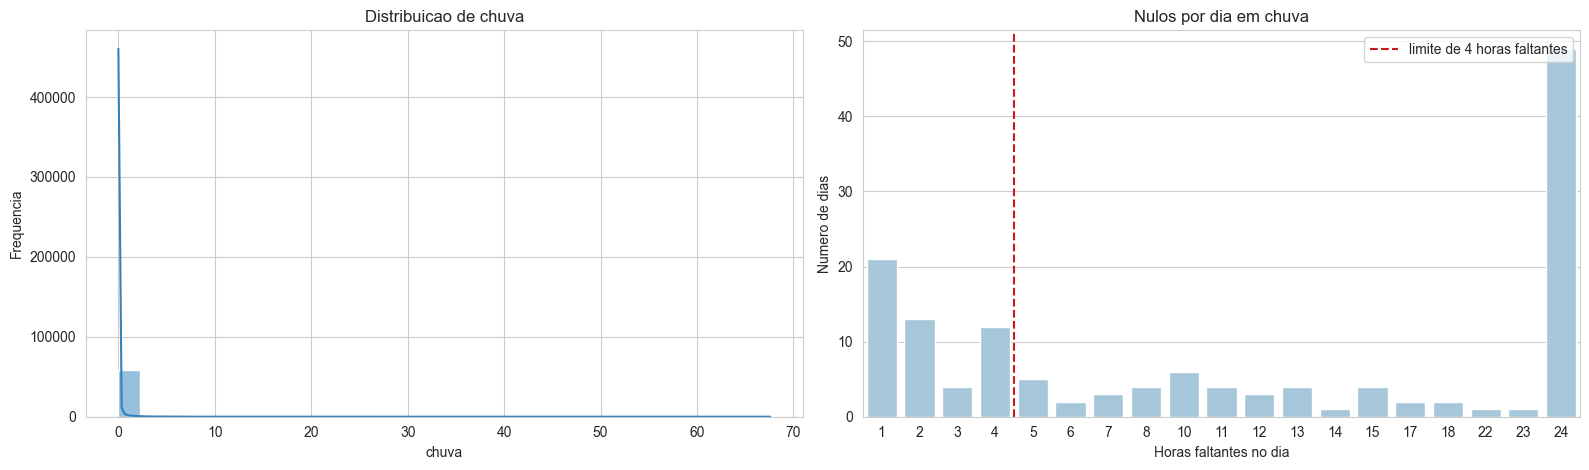

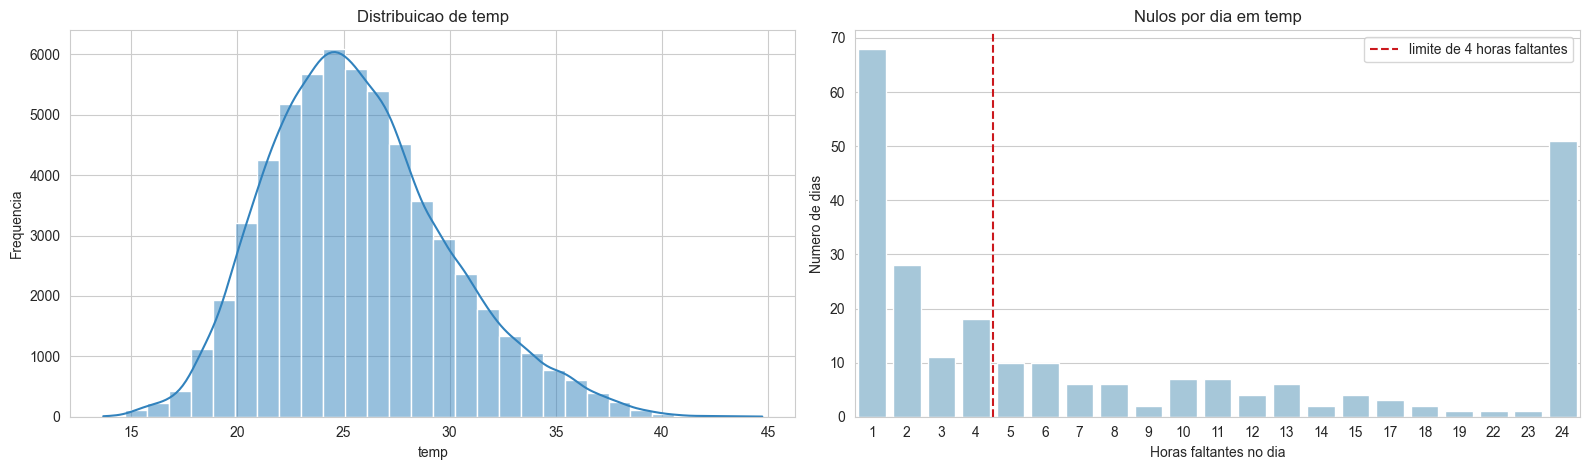

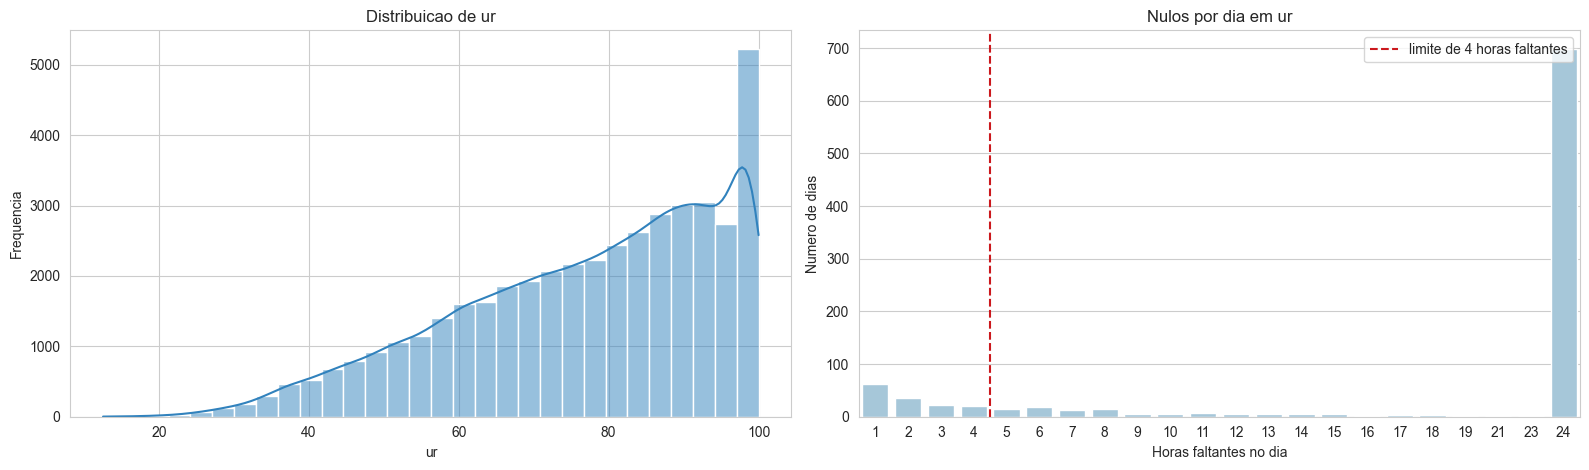

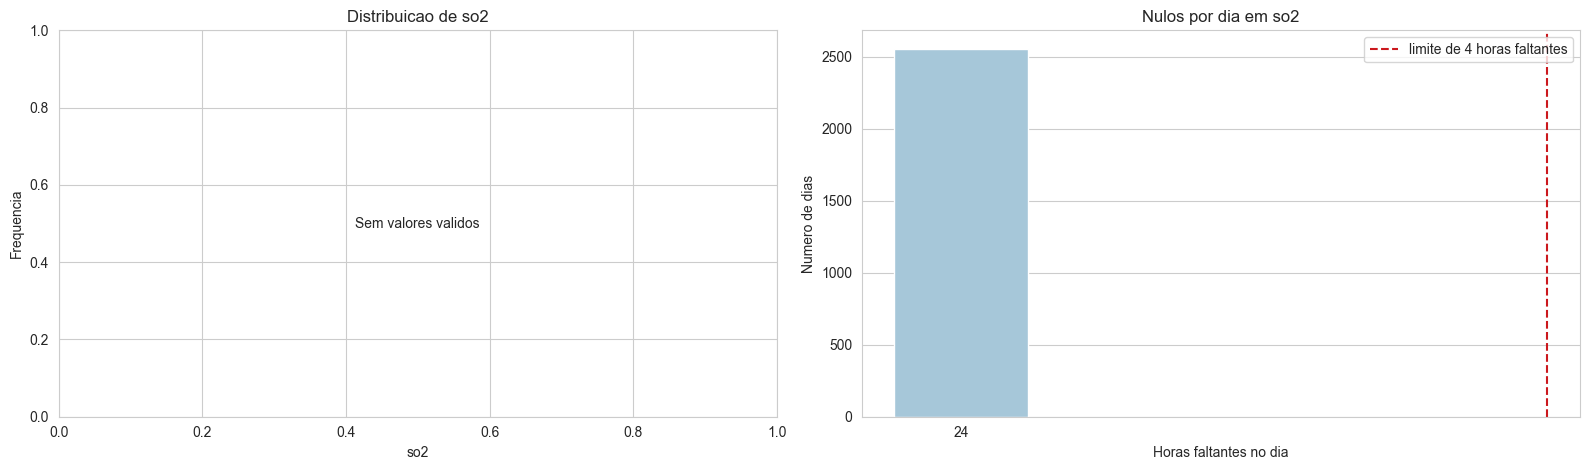

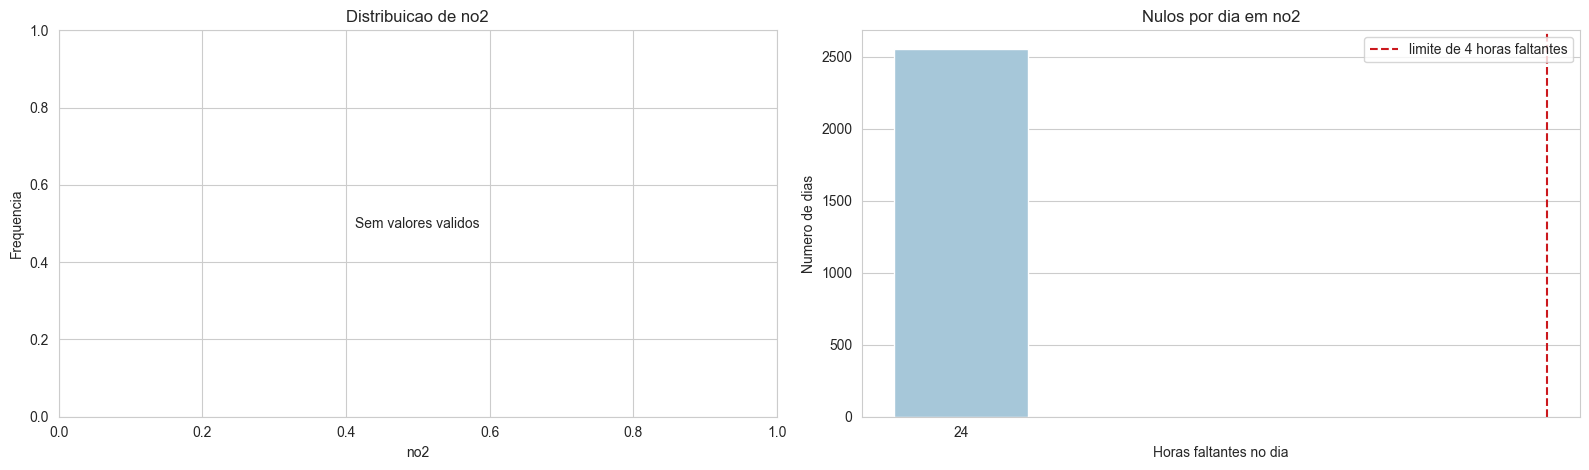

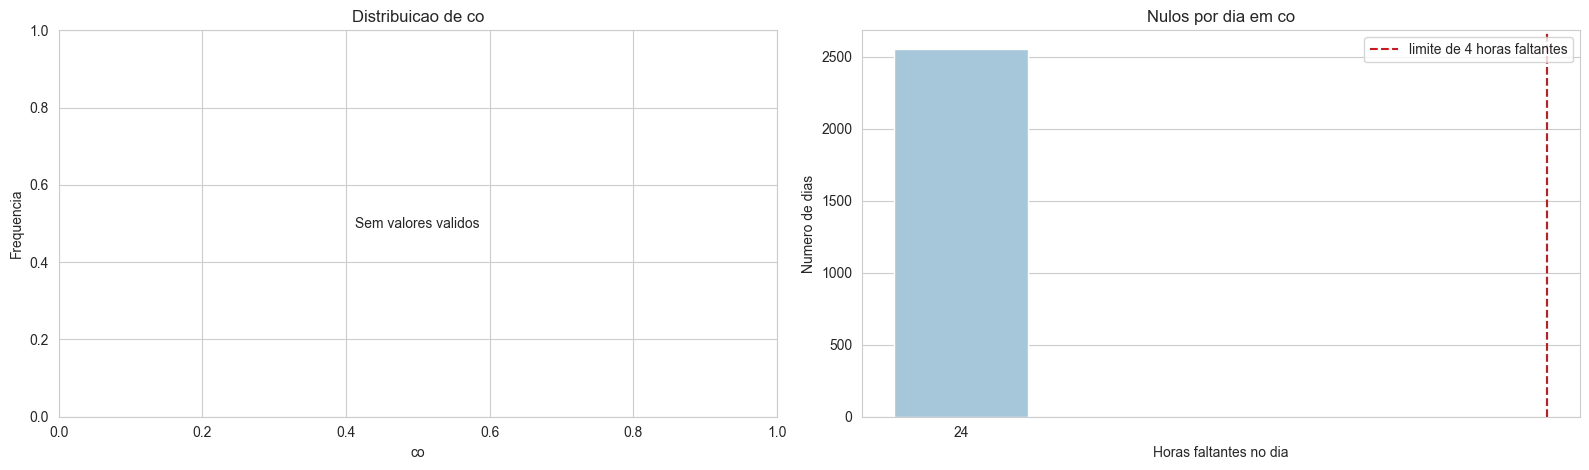

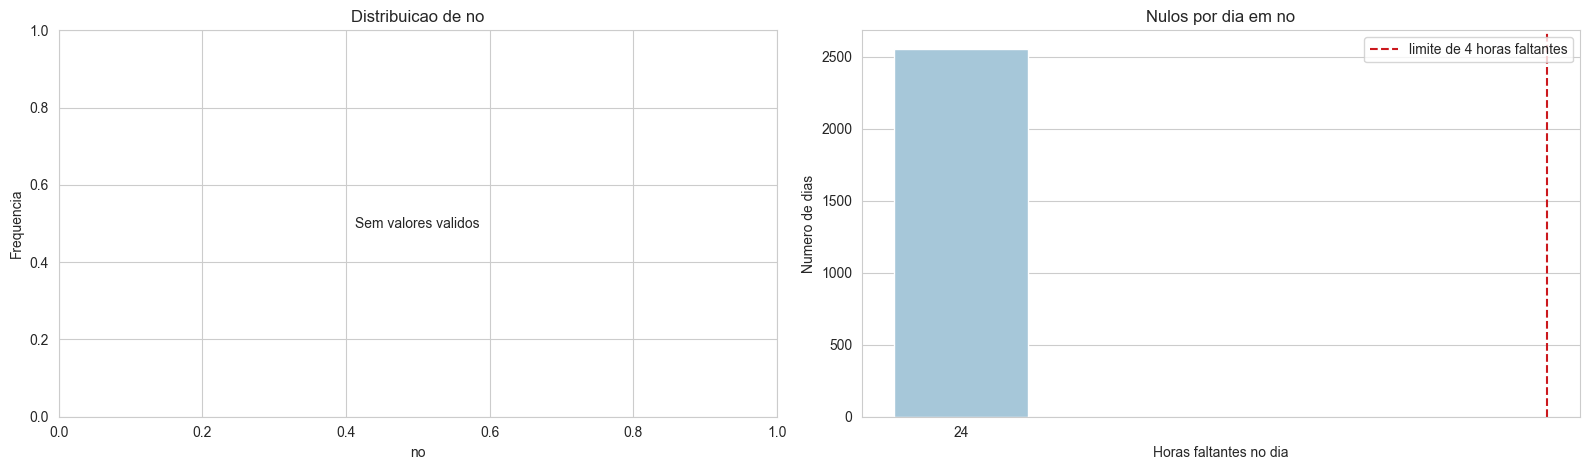

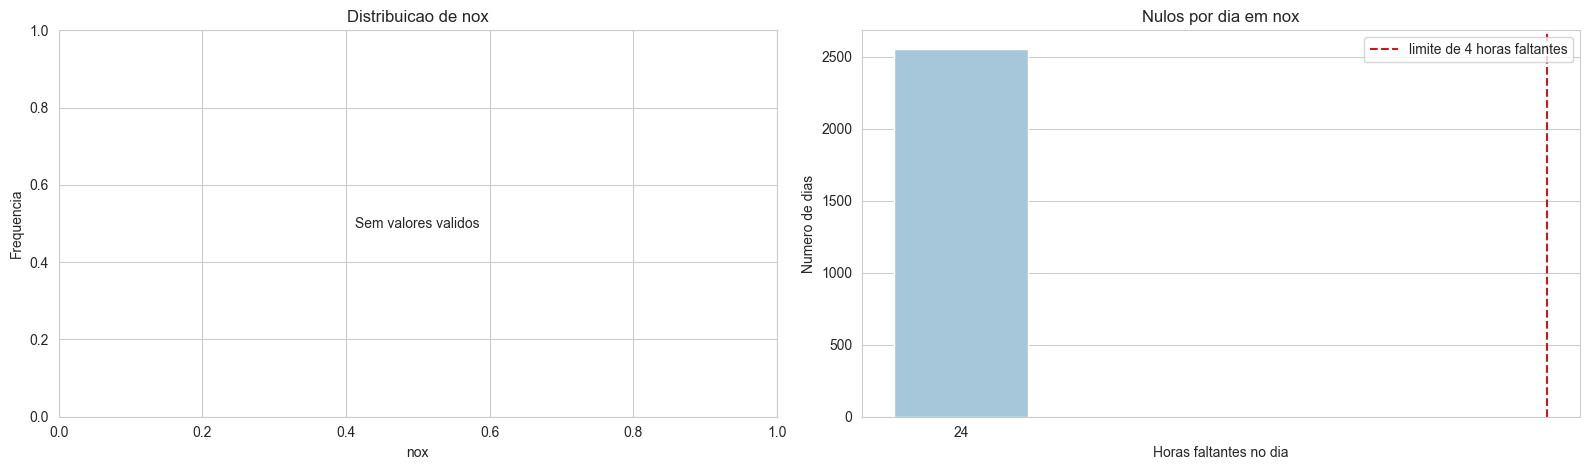

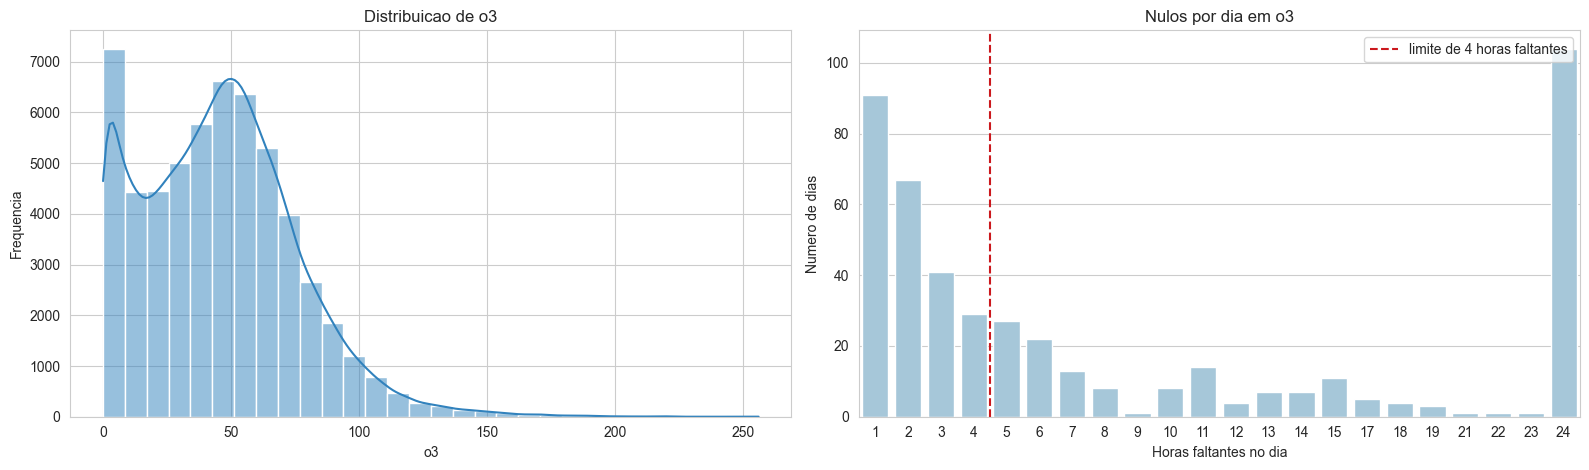

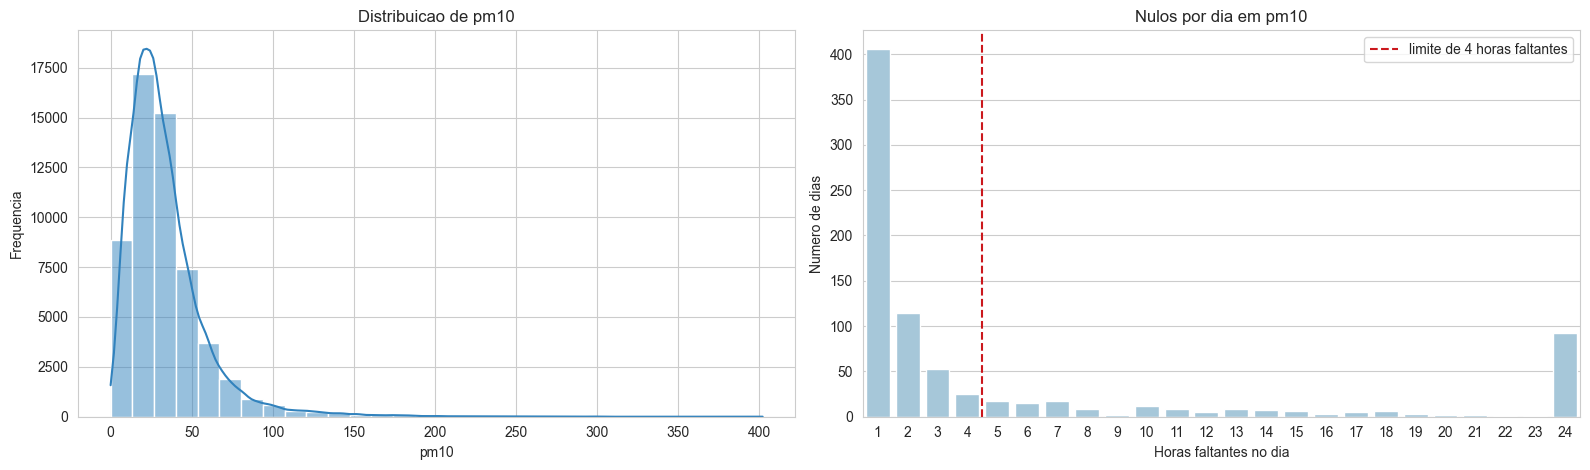

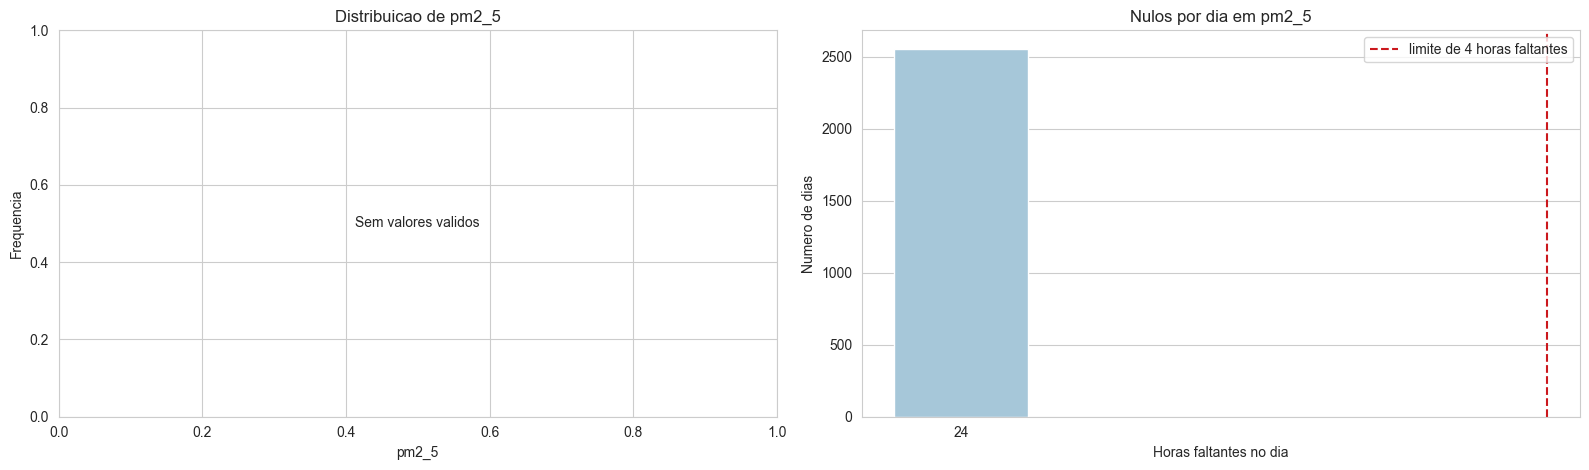

In [10]:
sns.set_style("whitegrid")

for variavel in variaveis_analise:
    serie = df_pedra_guaratiba_carac[variavel].dropna()
    faltantes_por_dia = distribuicoes_missing_diario[variavel]
    distribuicao_faltantes = (
        faltantes_por_dia.value_counts()
        .sort_index()
        .rename_axis("horas_faltantes")
        .reset_index(name="n_dias")
    )
    distribuicao_faltantes = distribuicao_faltantes[distribuicao_faltantes["horas_faltantes"] > 0].copy()

    fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))

    if not serie.empty:
        sns.histplot(serie, bins=30, kde=True, color="#3182bd", ax=axes[0])
    else:
        axes[0].text(0.5, 0.5, "Sem valores validos", ha="center", va="center", transform=axes[0].transAxes)

    axes[0].set_title(f"Distribuicao de {variavel}")
    axes[0].set_xlabel(variavel)
    axes[0].set_ylabel("Frequencia")

    if not distribuicao_faltantes.empty:
        sns.barplot(data=distribuicao_faltantes, x="horas_faltantes", y="n_dias", color="#9ecae1", ax=axes[1])
        axes[1].axvline(3.5, color="#cb181d", linestyle="--", linewidth=1.5, label="limite de 4 horas faltantes")
        axes[1].legend(loc="upper right")
    else:
        axes[1].text(0.5, 0.5, "Sem dias com horas faltantes", ha="center", va="center", transform=axes[1].transAxes)

    axes[1].set_title(f"Nulos por dia em {variavel}")
    axes[1].set_xlabel("Horas faltantes no dia")
    axes[1].set_ylabel("Numero de dias")

    plt.tight_layout()
    plt.show()

## Resumo interpretativo dos resultados

Os resultados indicam que a estação de Pedra de Guaratiba tem uma base **muito boa do ponto de vista temporal e operacional**, com cobertura de `2012-01-01 00:30` a `2018-12-31 23:30`, frequência horária regular, ausência de duplicatas de horário e estabilidade de nome e coordenadas. O ponto de atenção na linha do tempo é pequeno, mas existe: a série apresenta apenas `1` timestamp faltante em todo o período. Assim, a estrutura temporal da base continua bastante confiável, e o principal cuidado analítico passa a ser a disponibilidade desigual entre as variáveis monitoradas.

A leitura de missing por variável mostra uma separação muito forte de qualidade. Há um bloco inteiro de poluentes estruturalmente indisponíveis: `co`, `no`, `no2`, `nox`, `pm2_5` e `so2` aparecem com `100%` de nulos e, neste recorte, não devem ser tratados como séries analisáveis. Entre as variáveis restantes, `ur` ainda apresenta perda alta (`29,6%`), enquanto `pm10` (`7,3%`) e `o3` (`7,0%`) têm missing intermediário. Já `temp` (`3,6%`) e `chuva` (`2,9%`) se destacam como as séries mais completas da estação.

As distribuições reforçam que a estação monitora processos heterogêneos, mas com um conjunto observável mais restrito do que em outras estações. Entre as variáveis meteorológicas, `chuva` é fortemente concentrada em zero e muito assimétrica, `temp` apresenta comportamento relativamente estável e `ur` combina alta dispersão com perda relevante de dados. Entre os poluentes efetivamente disponíveis, `o3` e `pm10` mostram **assimetria à direita**, indicando predominância de valores usuais com alguns episódios elevados. Em Pedra de Guaratiba, chama atenção o nível central relativamente alto de `o3` (`45,6` de média e `44,8` de mediana), enquanto `pm10` apresenta dispersão maior e picos bem mais extremos, chegando a `402`. Isso sugere uma estação especialmente útil para estudar dinâmica de ozônio e material particulado, mas pouco informativa para gases como `NOx`, `NO2` e `CO`, que estão ausentes na base.

A distribuição diária de nulos também ajuda a separar o que é lacuna curta do que é indisponibilidade estrutural. `chuva` e `temp` concentram muitos dias completos e poucos dias severamente incompletos, o que favorece estratégias simples de imputação local. `o3` e `pm10` ainda preservam quantidade relevante de dias utilizáveis e parte das falhas está concentrada em lacunas curtas, embora `pm10` já exija mais cautela do que `o3`. `ur` volta a se destacar negativamente, porque combina missing total alto com muitos dias severamente incompletos. Já `co`, `no`, `no2`, `nox`, `pm2_5` e `so2` não apresentam um problema de preenchimento pontual: essas séries estão estruturalmente ausentes e devem ser tratadas como indisponíveis.

Em síntese, a estação de Pedra de Guaratiba parece **confiável como plataforma de monitoramento** no nível da base, porque a estrutura temporal é muito estável e o problema de calendário é mínimo. O principal limite analítico desta estação não está no relógio da série, mas no conjunto efetivamente disponível de sensores: `co`, `no`, `no2`, `nox`, `pm2_5` e `so2` devem ser excluídos ou marcados como indisponíveis, `ur` exige atenção especial por causa da incompletude elevada, e `chuva`, `temp`, `o3` e `pm10` podem seguir para as próximas etapas da EDA com boa utilidade. Isso deixa claro que, em Pedra de Guaratiba, a confiabilidade é alta no nível da base, mas a capacidade analítica fica concentrada em poucas variáveis com cobertura suficiente.
